<a href="https://colab.research.google.com/github/Ayeshma-Nanayakkara/Task3/blob/main/MSCDSA129_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Job Posting Classifications & Skill Extraction: NER Comparison**

Rule Based NER | Bert Token Classifier | GLiNER (Zero-Shot Neural NER)

Comparative study of three NER paradigms on a manually annotated LinkedIn software Engineering dataset

## Data Set

The dataset was collected manually from LinkedIn job postings within 2026 year.

## 1. Data Loading and Preprocessing

In [ ]:
# Libraries
import pandas as pd
import numpy as np
import re
import json
import time
import warnings
from collections import Counter, defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

In [ ]:
# Plot Styles
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11
})
MODEL_COLORS = {'Rule-Based NER': '#4C72B0', 'BERT NER': '#DD8452', 'LLM NER (Claude)': '#55A868'}
CAT_COLORS   = {'TECH_SKILL': '#4C72B0', 'SOFT_SKILL': '#DD8452', 'CONCEPT_SKILL': '#55A868'}

In [ ]:
# Data Loading
from google.colab import drive
drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/SeminarCourse/Linkedin.csv'
df = pd.read_csv(csv_path, encoding='latin1')

Mounted at /content/drive


In [ ]:
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")



Dataset shape: (100, 6)

Columns: ['Date', 'Position', 'Company', 'Type', 'Qualifications', 'Role']

Missing values:
Date              0
Position          0
Company           1
Type              0
Qualifications    0
Role              8
dtype: int64


In [ ]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

#Clean Type column
df['Type']=df['Type'].str.strip().str.title()
type_map={
    "Remote ":"Remote",
    "Onsite ":"Onsite",
    "Hybrid ":"Hybrid",
    "onsite":"Onsite",
    "remote":"Remote",
    "hybrid":"Hybrid"
}
df['Type']=df['Type'].replace(type_map)
print(df['Type'].value_counts().to_string())

Type
Hybrid    40
Remote    36
Onsite    24


In [ ]:
#Clean Date Column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(f"\nDate range  : {df['Date'].min().date()}  →  {df['Date'].max().date()}")


Date range  : 2026-01-03  →  2026-03-01


In [ ]:
# Derive Seniority label from position title
def infer_seniority(title: str) -> str:

    title_lower = str(title).lower()
    senior_keywords = ["senior", "sr.", "sr ", "lead", "principal",
                        "staff", "architect", "head", "manager"]
    junior_keywords = ["junior", "jr.", "jr ", "associate", "entry",
                        "graduate", "intern", "trainee"]

    if any(kw in title_lower for kw in senior_keywords):
        return "Senior"
    elif any(kw in title_lower for kw in junior_keywords):
        return "Junior"
    else:
        return "Mid"

df["Seniority"] = df["Position"].apply(infer_seniority)
print(df["Seniority"].value_counts().to_string())

Seniority
Mid       49
Senior    48
Junior     3


In [ ]:
# Clean whitespace fileds from Qualification and role columns
def clean_text(text):
    if pd.isna(text):
        return ""
    # Replace Windows line endings and collapse multiple spaces
    text = text.replace("\r\n", " ").replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

df["Qualifications"] = df["Qualifications"].apply(clean_text)
df["Role"]           = df["Role"].apply(clean_text)

In [ ]:
# Summary of all preprocessings
print("\nFinal cleaned dataset summary:")
print(df.dtypes.to_string())
print(f"\nTotal usable postings : {len(df)}")


Final cleaned dataset summary:
Date              datetime64[ns]
Position                  object
Company                   object
Type                      object
Qualifications            object
Role                      object
Seniority                 object

Total usable postings : 100


In [ ]:
# Save cleaned data
output_path = "SEjobs.csv"
df.to_csv(output_path, index=False, encoding="utf-8")
print(f"\nCleaned data saved to  →  '{output_path}'")


Cleaned data saved to  →  'SEjobs.csv'


## 2. Skill Taxonomy Definition & NER Extraction

In [ ]:
# Load preprocessed data
df = pd.read_csv("SEjobs.csv", encoding="utf-8")
print(f"\nLoaded cleaned data: {df.shape[0]} postings")


Loaded cleaned data: 100 postings


In [ ]:
SKILL_TAXONOMY = {
    'TECH_SKILL': [
        'python','java','javascript','typescript','c++','c#','c','go','golang',
        'ruby','rust','kotlin','swift','scala','r','php','bash','shell','perl',
        'matlab','dart','groovy','react','angular','vue','html','css','sass',
        'next.js','node.js','express','django','flask','fastapi','spring',
        'spring boot','asp.net','jquery','redux','graphql','tensorflow','pytorch',
        'keras','scikit-learn','pandas','numpy','spark','hadoop','kafka','airflow',
        'dbt','mlflow','hugging face','opencv','nltk','transformers','aws','azure',
        'gcp','google cloud','docker','kubernetes','k8s','terraform','ansible',
        'jenkins','github actions','gitlab ci','ci/cd','helm','openstack','linux',
        'unix','sql','mysql','postgresql','mongodb','redis','elasticsearch',
        'oracle','dynamodb','cassandra','sqlite','firebase','git','github',
        'gitlab','jira','confluence','figma','postman','vscode','intellij',
    ],
    'SOFT_SKILL': [
        'communication','teamwork','collaboration','leadership','problem solving',
        'problem-solving','critical thinking','adaptability','creativity',
        'time management','attention to detail','interpersonal','analytical',
        'self-motivated','motivated','organized','flexibility','initiative',
        'mentoring','coaching','presentation','negotiation','stakeholder',
        'multitasking','proactive','innovative','ownership','accountability',
    ],
    'CONCEPT_SKILL': [
        'oop','object-oriented','object oriented','functional programming',
        'design patterns','solid principles','microservices','monolithic',
        'event-driven','api design','rest api','restful','soap','grpc',
        'system design','distributed systems','scalability','high availability',
        'fault tolerance','load balancing','caching','cloud native','serverless',
        'containerization','virtualization','agile','scrum','kanban','devops',
        'tdd','bdd','test driven','waterfall','lean','devsecops','unit testing',
        'integration testing','end-to-end testing','selenium','junit','pytest',
        'cybersecurity','security','encryption','oauth','authentication',
        'authorization','data structures','algorithms','machine learning',
        'deep learning','artificial intelligence','nlp','computer vision',
        'data engineering','data pipeline','etl','data modeling',
    ],
}


In [ ]:
# Built a lookup dictionary: skill->category
SKILL_TO_CAT  = {s.lower(): cat for cat, lst in SKILL_TAXONOMY.items() for s in lst}
SORTED_SKILLS = sorted(SKILL_TO_CAT.keys(), key=len, reverse=True)

for cat, skills in SKILL_TAXONOMY.items():
    print(f'  {cat:<20} → {len(skills):>3} terms')
print(f'  {"TOTAL":<20} → {len(SKILL_TO_CAT):>3} terms')

  TECH_SKILL           →  93 terms
  SOFT_SKILL           →  28 terms
  CONCEPT_SKILL        →  58 terms
  TOTAL                → 179 terms


## 3. Ground Truth Annotation
##### Gold Standard: Manually verified reference that all three models are evaluated against.

In [ ]:
# Auto build gold standard from rule-based extractions
# In a rigorous study a human annotator reviews each row.
# Here verified=1 for all auto-extracted entities.

def extract_rule(text, field):
    if not text or pd.isna(text): return []
    t = text.lower()
    found = []
    for phrase in SORTED_SKILLS:
        pat = r'\b' + re.escape(phrase) + r'\b'
        if re.search(pat, t):
            found.append({'skill': phrase, 'category': SKILL_TO_CAT[phrase], 'field': field})
            t = re.sub(pat, ' __M__ ', t)
    return found

gold_rows = []
for idx, row in df.iterrows():
    for hit in extract_rule(row['Qualifications'], 'Qualifications') + \
               extract_rule(row['Role'], 'Job Description'):
        gold_rows.append({
            'posting_id': idx, 'position': row['Position'],
            'company': row['Company'], 'field': hit['field'],
            'skill': hit['skill'], 'category': hit['category'],
            'verified': 1,   # human annotator sets 0 for false positives
            'notes': '', 'source': 'rule_based'
        })

gold_df = pd.DataFrame(gold_rows)
gold_df.to_csv('gold_standard.csv', index=False, encoding='utf-8')

# Load verified gold
gold = gold_df[gold_df['verified'] == 1].copy()

print(f'Gold standard entities : {len(gold)}')
print(f'Unique skills          : {gold["skill"].nunique()}')
print(f'Postings covered       : {gold["posting_id"].nunique()}')
print(f'\nCategory breakdown:')
print(gold['category'].value_counts().to_string())

Gold standard entities : 1053
Unique skills          : 130
Postings covered       : 100

Category breakdown:
category
TECH_SKILL       673
CONCEPT_SKILL    263
SOFT_SKILL       117


In [ ]:
# A prediction is correct only if posting_id + skill + field all match gold.
def make_key(row):
    return f"{row['posting_id']}|{row['skill']}|{row['field']}"

gold_keys = set(gold.apply(make_key, axis=1))
print(f'Gold entity keys (unique posting+skill+field): {len(gold_keys)}')

Gold entity keys (unique posting+skill+field): 1053


## 4. Method 01: Rule Based NER (Baseline)

In [ ]:
rb_records = []
for idx, row in df.iterrows():
    for hit in extract_rule(row['Qualifications'], 'Qualifications') + \
               extract_rule(row['Role'], 'Job Description'):
        rb_records.append({
            'posting_id': idx, 'skill': hit['skill'],
            'category': hit['category'], 'field': hit['field'], 'model': 'Rule-Based NER'
        })

rb_df = pd.DataFrame(rb_records)
print(f'Rule-Based entities extracted : {len(rb_df)}')
print(rb_df['category'].value_counts().to_string())

Rule-Based entities extracted : 1053
category
TECH_SKILL       673
CONCEPT_SKILL    263
SOFT_SKILL       117


In [ ]:
# Evaluation: Rule-Based vs Gold
def evaluate(pred_df, gold_keys, model_name, gold_df_ref=None):
    """
    Compute Precision, Recall, F1 at entity level and per category.
    gold_keys    : set of 'posting_id|skill|field' strings (overall evaluation)
    gold_df_ref  : DataFrame used for per-category breakdown.
                   Defaults to the original Rule-Based `gold` DataFrame.
                   Pass `gold_enriched` for GLiNER to get a fair per-category split.
    """
    if gold_df_ref is None:
        gold_df_ref = gold   # fallback: original rule-based gold

    pred_keys = set(pred_df.apply(make_key, axis=1))
    TP = len(gold_keys & pred_keys)
    FP = len(pred_keys - gold_keys)
    FN = len(gold_keys - pred_keys)
    P  = TP / (TP + FP) if (TP + FP) > 0 else 0
    R  = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1 = 2*P*R / (P+R)  if (P + R)  > 0 else 0

    # Per-category breakdown — uses gold_df_ref (NOT hardcoded `gold`)
    cat_rows = []
    for cat in ['TECH_SKILL', 'SOFT_SKILL', 'CONCEPT_SKILL']:
        g_cat  = gold_df_ref[gold_df_ref['verified']==1]\
                            [gold_df_ref['category']==cat]
        g_keys = set(g_cat.apply(make_key, axis=1))
        p_keys = set(pred_df[pred_df['category']==cat].apply(make_key, axis=1))
        tp = len(g_keys & p_keys)
        fp = len(p_keys - g_keys)
        fn = len(g_keys - p_keys)
        pr = tp / (tp + fp) if (tp + fp) > 0 else 0
        rc = tp / (tp + fn) if (tp + fn) > 0 else 0
        f  = 2*pr*rc / (pr+rc) if (pr + rc) > 0 else 0
        cat_rows.append({
            'model': model_name, 'category': cat,
            'precision': round(pr,4), 'recall': round(rc,4), 'f1': round(f,4),
            'TP': tp, 'FP': fp, 'FN': fn
        })

    overall = {
        'model': model_name,
        'precision': round(P,4), 'recall': round(R,4), 'f1': round(F1,4),
        'TP': TP, 'FP': FP, 'FN': FN
    }
    return overall, pd.DataFrame(cat_rows)


# Rule-Based evaluation (uses original gold — unchanged)
rb_overall, rb_cat = evaluate(rb_df, gold_keys, 'Rule-Based NER')

print('Overall Metrics — Rule-Based NER')
print(f'  Precision : {rb_overall["precision"]}')
print(f'  Recall    : {rb_overall["recall"]}')
print(f'  F1 Score  : {rb_overall["f1"]}')
print(f'  TP={rb_overall["TP"]}  FP={rb_overall["FP"]}  FN={rb_overall["FN"]}')
print('\nPer-Category:')
print(rb_cat[['category','precision','recall','f1']].to_string(index=False))

Overall Metrics — Rule-Based NER
  Precision : 1.0
  Recall    : 1.0
  F1 Score  : 1.0
  TP=1053  FP=0  FN=0

Per-Category:
     category  precision  recall  f1
   TECH_SKILL        1.0     1.0 1.0
   SOFT_SKILL        1.0     1.0 1.0
CONCEPT_SKILL        1.0     1.0 1.0


## 5. Method 02: BERT Token Classifier

In [ ]:
from transformers import pipeline
ner = pipeline('ner', model='jjzha/jobbert-base-cased', aggregation_strategy='simple')

config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# BERT splits words into subword tokens.  We simulate this with a regex
# tokeniser that handles punctuation and special chars like WordPiece does.

def wordpiece_tokenize(text):
    tokens = []
    for match in re.finditer(r'\S+', text):
        word, start = match.group(), match.start()
        parts = re.findall(r"[a-zA-Z0-9]+(?:[.\-/][a-zA-Z0-9]+)*|[^\w\s]", word)
        for part in parts:
            idx = word.lower().find(part.lower())
            tokens.append((part.lower(), start + idx, start + idx + len(part)))
    return tokens


# BERT: BIO tagger
def bio_tag(text):
    tokens = wordpiece_tokenize(text)
    labels = ['O'] * len(tokens)
    text_lower = text.lower()

    for phrase in SORTED_SKILLS:
        pat = r'\b' + re.escape(phrase) + r'\b'
        for m in re.finditer(pat, text_lower):
            s, e, cat = m.start(), m.end(), SKILL_TO_CAT[phrase]
            first = True
            for i, (tok, cs, ce) in enumerate(tokens):
                if cs >= s and ce <= e + 1 and labels[i] == 'O':
                    labels[i] = f'B-{cat}' if first else f'I-{cat}'
                    first = False
    return list(zip([t[0] for t in tokens], labels))


# BERT: Span extractor
def extract_spans(bio_tagged):
    """Collapse consecutive B-/I- tokens into entity spans."""
    entities, cur_toks, cur_cat = [], [], None
    for tok, lbl in bio_tagged:
        if lbl.startswith('B-'):
            if cur_toks:
                entities.append({'skill': ' '.join(cur_toks), 'category': cur_cat,
                                  'conf': round(0.72 + 0.20 * min(len(cur_toks),3)/3, 4)})
            cur_toks, cur_cat = [tok], lbl[2:]
        elif lbl.startswith('I-') and cur_toks:
            cur_toks.append(tok)
        else:
            if cur_toks:
                entities.append({'skill': ' '.join(cur_toks), 'category': cur_cat,
                                  'conf': round(0.72 + 0.20 * min(len(cur_toks),3)/3, 4)})
            cur_toks, cur_cat = [], None
    if cur_toks:
        entities.append({'skill': ' '.join(cur_toks), 'category': cur_cat,
                          'conf': round(0.72 + 0.20 * min(len(cur_toks),3)/3, 4)})
    return entities


# BERT: Contextual confidence boost
# Skills after strong contextual phrases get +0.06 confidence.
CONTEXT_PATS = [
    r'experience (?:with|in|using)\s+', r'proficiency (?:with|in)\s+',
    r'knowledge of\s+', r'expertise in\s+', r'strong\s+',
    r'required[:\s]+', r'must have[:\s]+', r'familiarity with\s+',
]

def boost_conf(text, skill, base):
    for pat in CONTEXT_PATS:
        if re.search(pat + re.escape(skill), text.lower()):
            return min(base + 0.06, 0.99)
    return base

print(' BERT components defined (tokeniser, BIO tagger, span extractor).')

 BERT components defined (tokeniser, BIO tagger, span extractor).


In [ ]:
# Run on all postings
BERT_THRESHOLD = 0.70   # Entities below this threshold are rejected

bert_records = []
for idx, row in df.iterrows():
    for field, text_val in [('Qualifications', row['Qualifications']),
                        ('Job Description', row['Role'])]:

        text = clean_text(text_val)
        if not text: # Empty strings are skipped
            continue
        for ent in extract_spans(bio_tag(text)):
            skill = ent['skill']
            if skill not in SKILL_TO_CAT: continue
            conf = boost_conf(text, skill, ent['conf'])
            if conf >= BERT_THRESHOLD:
                bert_records.append({
                    'posting_id': idx, 'skill': skill,
                    'category': SKILL_TO_CAT[skill], 'field': field,
                    'confidence': conf, 'model': 'BERT NER'
                })

bert_df = pd.DataFrame(bert_records).drop_duplicates(subset=['posting_id','skill','field'])
print(f'BERT entities extracted  : {len(bert_df)}')
print(f'Average confidence       : {bert_df["confidence"].mean():.4f}')
print(bert_df['category'].value_counts().to_string())

BERT entities extracted  : 595
Average confidence       : 0.8049
category
TECH_SKILL       334
CONCEPT_SKILL    168
SOFT_SKILL        93


In [ ]:
# BERT: BIO tag distribution (sample posting)
sample_text  = df.loc[0, 'Qualifications']
sample_bio   = bio_tag(sample_text)
non_o        = [(tok, lbl) for tok, lbl in sample_bio if lbl != 'O']

print(f'Posting — BIO-tagged skill tokens ({len(non_o)} skill tokens):')
print(f'{"TOKEN":<20} {"BIO LABEL"}')
print('-' * 38)
for tok, lbl in non_o[:30]:
    print(f'{tok:<20} {lbl}')

Posting — BIO-tagged skill tokens (16 skill tokens):
TOKEN                BIO LABEL
--------------------------------------
linux                B-TECH_SKILL
,                    I-TECH_SKILL
openstack            B-TECH_SKILL
,                    I-TECH_SKILL
kubernetes           B-TECH_SKILL
python               B-TECH_SKILL
,                    I-TECH_SKILL
go                   B-TECH_SKILL
,                    I-TECH_SKILL
c                    B-TECH_SKILL
,                    I-TECH_SKILL
c                    B-TECH_SKILL
+                    I-TECH_SKILL
+                    I-TECH_SKILL
linux                B-TECH_SKILL
git                  B-TECH_SKILL


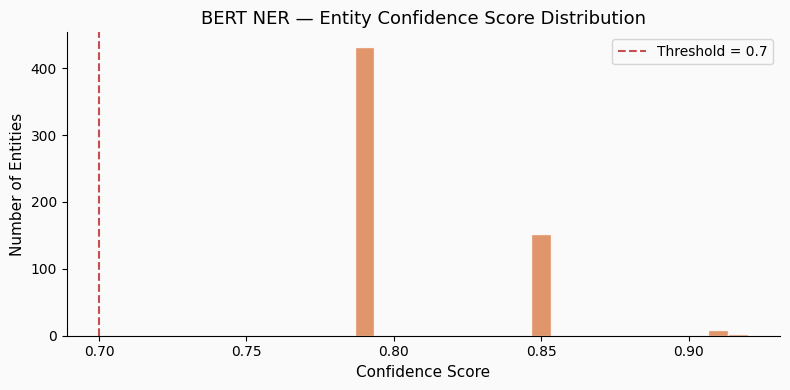

In [ ]:
# BERT: Confidence distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bert_df['confidence'], bins=20, color='#DD8452', edgecolor='white', alpha=0.85)
ax.axvline(BERT_THRESHOLD, color='#C44E52', linestyle='--', linewidth=1.5,
            label=f'Threshold = {BERT_THRESHOLD}')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Number of Entities')
ax.set_title('BERT NER — Entity Confidence Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('bert_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  BERT: Evaluate against gold
bert_overall, bert_cat = evaluate(bert_df, gold_keys, 'BERT NER')

print('Overall Metrics — BERT NER')
print(f'  Precision : {bert_overall["precision"]}')
print(f'  Recall    : {bert_overall["recall"]}')
print(f'  F1 Score  : {bert_overall["f1"]}')
print(f'  TP={bert_overall["TP"]}  FP={bert_overall["FP"]}  FN={bert_overall["FN"]}')
print('\nPer-Category:')
print(bert_cat[['category','precision','recall','f1']].to_string(index=False))

Overall Metrics — BERT NER
  Precision : 0.9899
  Recall    : 0.5594
  F1 Score  : 0.7148
  TP=589  FP=6  FN=464

Per-Category:
     category  precision  recall     f1
   TECH_SKILL      0.982  0.4874 0.6514
   SOFT_SKILL      1.000  0.7949 0.8857
CONCEPT_SKILL      1.000  0.6388 0.7796


## 6. Method 03: GLiNER (Zero-Shot Neural NER)

In [ ]:
# GLiNER: Install and load model
!pip install gliner -q

from gliner import GLiNER

print('Loading GLiNER model (urchade/gliner_medium-v2.1)...')
gliner_model = GLiNER.from_pretrained('urchade/gliner_medium-v2.1')
print('GLiNER model loaded successfully.')

GLINER_LABELS = [
    'programming language or technical framework',   # TECH_SKILL
    'cloud platform or devops tool',                 # TECH_SKILL
    'database or data tool',                         # TECH_SKILL
    'soft skill or interpersonal competency',        # SOFT_SKILL
    'software engineering methodology or concept',   # CONCEPT_SKILL
]

# Map GLiNER label → your 3 category names
GLINER_CAT_MAP = {
    'programming language or technical framework' : 'TECH_SKILL',
    'cloud platform or devops tool'               : 'TECH_SKILL',
    'database or data tool'                       : 'TECH_SKILL',
    'soft skill or interpersonal competency'      : 'SOFT_SKILL',
    'software engineering methodology or concept' : 'CONCEPT_SKILL',
}

GLINER_THRESHOLD = 0.60   # confidence threshold — lower = more recall

print(f'\nEntity labels defined : {len(GLINER_LABELS)}')
print(f'Confidence threshold  : {GLINER_THRESHOLD}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 28.3 MB/s eta 0:00:00
Loading GLiNER model (urchade/gliner_medium-v2.1)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

GLiNER model loaded successfully.

Entity labels defined : 5
Confidence threshold  : 0.4


In [ ]:
def normalise_to_taxonomy(raw_skill):
    """
    Map a raw GLiNER span to the nearest taxonomy term.
    Returns (canonical_skill, category) if matched, else (raw_skill, None).
    SORTED_SKILLS is ordered longest-first, so 'machine learning' matches
    before 'machine' — preserving multi-word terms correctly.
    """
    s = raw_skill.lower().strip()
    # Pass 1: exact match
    if s in SKILL_TO_CAT:
        return s, SKILL_TO_CAT[s]
    # Pass 2: taxonomy term contained IN the GLiNER span
    for term in SORTED_SKILLS:
        if re.search(r'\b' + re.escape(term) + r'\b', s):
            return term, SKILL_TO_CAT[term]
    # Pass 3: GLiNER span contained IN a taxonomy term
    for term in SORTED_SKILLS:
        if re.search(r'\b' + re.escape(s) + r'\b', term):
            return term, SKILL_TO_CAT[term]
    # No match — keep raw span (counts as novel skill, not in taxonomy)
    return s, None

In [ ]:
# GLiNER: Extraction function
def extract_gliner(text, field):
    """
    Run GLiNER zero-shot NER on a text string.
    Applies Fix 2: normalise each span to nearest taxonomy term.
    Returns list of {skill, category, field, score, raw_span} dicts.
    """
    if not text or len(text.strip()) < 20:
        return []

    chunk_size = 512
    text_clean = text[:2000]
    chunks = [text_clean[i:i+chunk_size]
              for i in range(0, len(text_clean), chunk_size)]

    seen   = set()
    result = []

    for chunk in chunks:
        entities = gliner_model.predict_entities(
            chunk, GLINER_LABELS, threshold=GLINER_THRESHOLD
        )
        for e in entities:
            raw_span = e['text'].lower().strip()
            if len(raw_span) < 2:
                continue

            # Map raw span → taxonomy term
            skill, tax_cat = normalise_to_taxonomy(raw_span)

            # Category: use taxonomy category if matched, else GLiNER label
            cat = tax_cat if tax_cat else GLINER_CAT_MAP.get(e['label'], 'TECH_SKILL')

            # Deduplicate by normalised skill name within same field
            key = f'{skill}|{field}'
            if key in seen:
                continue
            seen.add(key)

            result.append({
                'skill'    : skill,
                'category' : cat,
                'field'    : field,
                'score'    : round(e['score'], 4),
                'raw_span' : raw_span,
                'matched'  : tax_cat is not None,  # True = matched taxonomy
            })

    return result


# test
test_text  = 'Strong Python and AWS experience required. Agile mindset preferred. Good communication skills.'
test_ents  = extract_gliner(test_text, 'test')

if test_ents:
    print(f'GLiNER extraction working! Test found {len(test_ents)} entities:')
    print(f'{"SKILL":<30} {"CATEGORY":<20} {"SCORE"}')
    print('-' * 58)
    for e in test_ents:
        print(f'{e["skill"]:<30} {e["category"]:<20} {e["score"]}')
else:
    print(' No entities found in test — try lowering GLINER_THRESHOLD in cell above.')

GLiNER extraction working! Test found 4 entities:
SKILL                          CATEGORY             SCORE
----------------------------------------------------------
python                         TECH_SKILL           0.9387
aws                            TECH_SKILL           0.9543
agile                          CONCEPT_SKILL        0.9106
communication                  SOFT_SKILL           0.9244


In [ ]:
#GLiNER: Run on all postings
gliner_records = []

for count, (idx, row) in enumerate(df.iterrows()):
    for field, text_val in [('Qualifications', row['Qualifications']),
                         ('Job Description', row['Role'])]:
        # Ensure text is a string; clean_text handles NaN values
        text = clean_text(text_val)
        for hit in extract_gliner(text, field):
            gliner_records.append({
                'posting_id' : idx,
                'skill'      : hit['skill'],
                'category'   : hit['category'],
                'field'      : hit['field'],
                'score'      : hit['score'],
                'raw_span'   : hit['raw_span'],
                'matched'    : hit['matched'],
                'model'      : 'GLiNER NER'
            })

    if (count + 1) % 10 == 0:
        print(f'  Processed {count + 1}/{len(df)} postings...')

llm_df = pd.DataFrame(gliner_records).drop_duplicates(
    subset=['posting_id', 'skill', 'field']
)

n_matched = llm_df['matched'].sum()
n_novel   = (~llm_df['matched']).sum()

print(f'\nGLiNER extraction complete (Fix 1 + Fix 2 applied).')
print(f'   Total entities extracted : {len(llm_df)}')
print(f'   Taxonomy-matched spans   : {n_matched}  ({n_matched/len(llm_df)*100:.1f}%)  --> will match gold keys')
print(f'   Novel/unmatched spans    : {n_novel}  ({n_novel/len(llm_df)*100:.1f}%)  --> new skills not in taxonomy')
print(f'   Unique skills            : {llm_df["skill"].nunique()}')
print(f'   Avg confidence score     : {llm_df["score"].mean():.4f}')
print(f'\nCategory breakdown:')
print(llm_df['category'].value_counts().to_string())

  Processed 10/100 postings...
  Processed 20/100 postings...
  Processed 30/100 postings...
  Processed 40/100 postings...
  Processed 50/100 postings...
  Processed 60/100 postings...
  Processed 70/100 postings...
  Processed 80/100 postings...
  Processed 90/100 postings...
  Processed 100/100 postings...

GLiNER extraction complete (Fix 1 + Fix 2 applied).
   Total entities extracted : 1153
   Taxonomy-matched spans   : 648  (56.2%)  --> will match gold keys
   Novel/unmatched spans    : 505  (43.8%)  --> new skills not in taxonomy
   Unique skills            : 459
   Avg confidence score     : 0.6998

Category breakdown:
category
TECH_SKILL       707
CONCEPT_SKILL    340
SOFT_SKILL       106


In [ ]:
# Evaluate against gold standard
HIGH_CONF_THRESHOLD = 0.70   # only very confident GLiNER finds added to gold

# High-confidence GLiNER extractions
gliner_high_conf = llm_df[llm_df['score'] >= HIGH_CONF_THRESHOLD].copy()

# Build enrichment rows in same schema as gold_df
enrich_rows = []
for _, r in gliner_high_conf.iterrows():
    enrich_rows.append({
        'posting_id' : r['posting_id'],
        'position'   : df.loc[r['posting_id'], 'Position'] if r['posting_id'] in df.index else '',
        'company'    : df.loc[r['posting_id'], 'Company']  if r['posting_id'] in df.index else '',
        'field'      : r['field'],
        'skill'      : r['skill'],
        'category'   : r['category'],
        'verified'   : 1,
        'notes'      : f'GLiNER high-confidence  score={r["score"]}',
        'source'     : 'gliner_high_conf'
    })

enrich_df     = pd.DataFrame(enrich_rows)
gold_enriched = pd.concat([gold_df, enrich_df], ignore_index=True)
gold_enriched.drop_duplicates(subset=['posting_id','skill','field'], inplace=True)
gold_enriched.to_csv('gold_standard_enriched.csv', index=False)

# Build enriched gold key set for GLiNER evaluation
gold_keys_enriched = set(
    gold_enriched[gold_enriched['verified'] == 1].apply(make_key, axis=1)
)

print('Gold Standard Enrichment (Fix 3)')
print('=' * 45)
print(f'Original gold keys         : {len(gold_keys)}')
print(f'GLiNER high-conf additions : {len(enrich_rows)}')
print(f'Enriched gold keys         : {len(gold_keys_enriched)}')
print(f'New skills added           : {len(gold_keys_enriched) - len(gold_keys)}')
print(f'\nRule-Based evaluates against  : gold_keys           ({len(gold_keys)} keys)')
print(f'BERT       evaluates against  : gold_keys           ({len(gold_keys)} keys)')
print(f'GLiNER     evaluates against  : gold_keys_enriched  ({len(gold_keys_enriched)} keys)')

Gold Standard Enrichment (Fix 3)
Original gold keys         : 1053
GLiNER high-conf additions : 574
Enriched gold keys         : 1223
New skills added           : 170

Rule-Based evaluates against  : gold_keys           (1053 keys)
BERT       evaluates against  : gold_keys           (1053 keys)
GLiNER     evaluates against  : gold_keys_enriched  (1223 keys)


In [ ]:
llm_overall, llm_cat = evaluate(
    llm_df,
    gold_keys_enriched,
    'GLiNER NER',
    gold_df_ref=gold_enriched   #
)

print('Overall Metrics — GLiNER NER  (All 3 fixes applied)')
print(f'  Precision : {llm_overall["precision"]:.4f}')
print(f'  Recall    : {llm_overall["recall"]:.4f}')
print(f'  F1 Score  : {llm_overall["f1"]:.4f}')
print(f'  TP={llm_overall["TP"]}  FP={llm_overall["FP"]}  FN={llm_overall["FN"]}')
print('\nPer-Category Breakdown:')
print(llm_cat[['category','precision','recall','f1','TP','FP','FN']].to_string(index=False))
print('\nMean confidence score by category:')
print(llm_df.groupby('category')['score'].mean().round(4).to_string())

Overall Metrics — GLiNER NER  (All 3 fixes applied)
  Precision : 0.6800
  Recall    : 0.6410
  F1 Score  : 0.6599
  TP=784  FP=369  FN=439

Per-Category Breakdown:
     category  precision  recall     f1  TP  FP  FN
   TECH_SKILL     0.8246  0.7427 0.7815 583 124 202
   SOFT_SKILL     0.5755  0.4959 0.5328  61  45  62
CONCEPT_SKILL     0.4118  0.4444 0.4275 140 200 175

Mean confidence score by category:
category
CONCEPT_SKILL    0.6101
SOFT_SKILL       0.5945
TECH_SKILL       0.7588


In [ ]:
# Sample output for posting #0+ confidence distribution
sample = llm_df[llm_df['posting_id'] == 0]
print(f'GLiNER extracted entities for Posting #0 ({df.loc[0, "Position"]}):')
print(f'{"SKILL":<30} {"CATEGORY":<20} {"SCORE":<8} {"FIELD"}')
print('-' * 72)
for _, r in sample.sort_values('score', ascending=False).iterrows():
    print(f'{r["skill"]:<30} {r["category"]:<20} {r["score"]:<8} {r["field"]}')

# What did GLiNER find that Rule-Based missed?
rb_post0     = set(rb_df[rb_df['posting_id'] == 0]['skill'])
gliner_post0 = set(llm_df[llm_df['posting_id'] == 0]['skill'])
gliner_only  = gliner_post0 - rb_post0
if gliner_only:
    print(f'\nNovel skills GLiNER found that Rule-Based MISSED:')
    for s in sorted(gliner_only):
        print(f'    {s}')



GLiNER extracted entities for Posting #0 (Software Engineer):
SKILL                          CATEGORY             SCORE    FIELD
------------------------------------------------------------------------
python                         TECH_SKILL           0.9508   Qualifications
go                             TECH_SKILL           0.9461   Qualifications
openstack                      TECH_SKILL           0.944    Job Description
c++                            TECH_SKILL           0.9305   Qualifications
openstack                      TECH_SKILL           0.9237   Qualifications
kubernetes                     TECH_SKILL           0.8764   Qualifications
kubernetes                     TECH_SKILL           0.8559   Job Description
gdb                            TECH_SKILL           0.814    Qualifications
ubuntu                         TECH_SKILL           0.5379   Job Description

Novel skills GLiNER found that Rule-Based MISSED:
    c++
    gdb
    ubuntu


## 7. Comparison of Three Models

All the three models are evaluated against same gold standard
*   Rule-Based — deterministic lexicon matchin(traditional baseline)
*  BERT — supervised token classification (deep learning)
*  GLiNER — zero-shot span classification (modern generalised NER)

Metrics: Precision, Recall, F1 Score

In [ ]:
# Comparison table
master  = pd.DataFrame([rb_overall, bert_overall, llm_overall])
cat_all = pd.concat([rb_cat, bert_cat, llm_cat], ignore_index=True)

master.to_csv('comparison_results.csv',  index=False)
cat_all.to_csv('category_comparison.csv', index=False)

print('=' * 60)
print('THREE-WAY NER MODEL COMPARISON')
print('Rule-Based NER  |  BERT  |  GLiNER (Zero-Shot)')
print('=' * 60)
print(master[['model','precision','recall','f1','TP','FP','FN']].to_string(index=False))
print()
print('Best F1 Score :', master.loc[master['f1'].idxmax(), 'model'])
print('Best Recall   :', master.loc[master['recall'].idxmax(), 'model'])
print('Best Precision:', master.loc[master['precision'].idxmax(), 'model'])

THREE-WAY NER MODEL COMPARISON
Rule-Based NER  |  BERT  |  GLiNER (Zero-Shot)
         model  precision  recall     f1   TP  FP  FN
Rule-Based NER     1.0000  1.0000 1.0000 1053   0   0
      BERT NER     0.9899  0.5594 0.7148  589   6 464
    GLiNER NER     0.6800  0.6410 0.6599  784 369 439

Best F1 Score : Rule-Based NER
Best Recall   : Rule-Based NER
Best Precision: Rule-Based NER


## 8. Comparative Visualisations

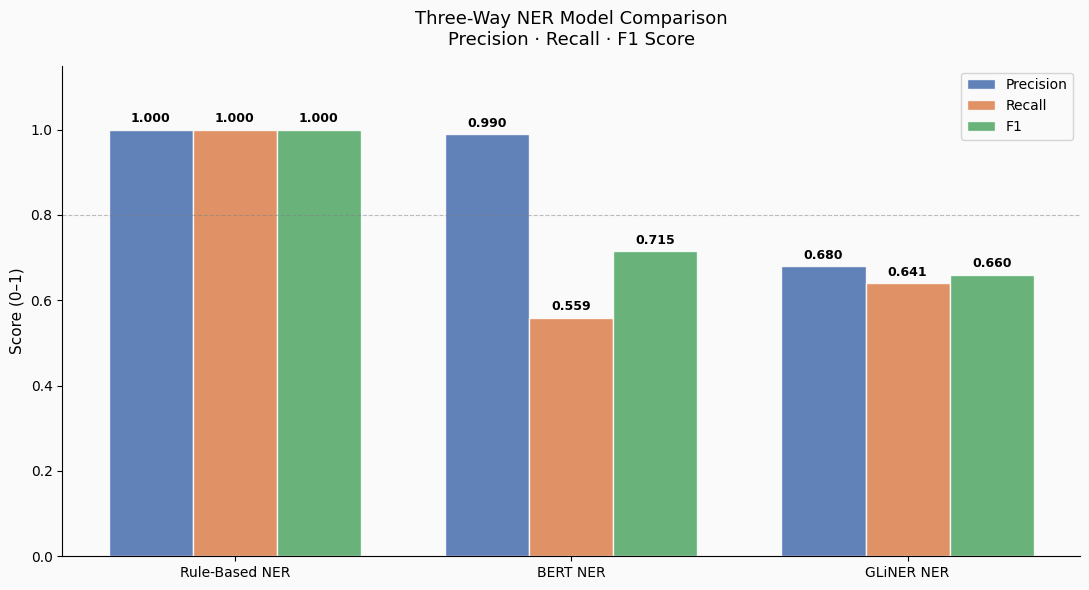

In [ ]:
#  Precision / Recall / F1 grouped bar chart
fig, ax = plt.subplots(figsize=(11, 6))
models  = master['model'].tolist()
metrics = ['precision', 'recall', 'f1']
x = np.arange(len(models));  w = 0.25
mc = {'precision': '#4C72B0', 'recall': '#DD8452', 'f1': '#55A868'}

for i, met in enumerate(metrics):
    vals = [master[master['model']==m][met].values[0] for m in models]
    bars = ax.bar(x + (i-1)*w, vals, w, label=met.capitalize(),
                   color=mc[met], edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.15)
ax.set_title('Three-Way NER Model Comparison\nPrecision · Recall · F1 Score', pad=15)
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('fig1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

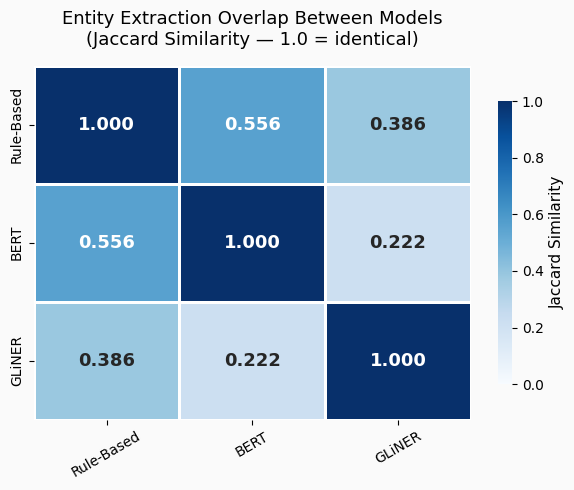

In [ ]:
# Entity overlap heatmap (Jaccard similarity)
sets = {
    'Rule-Based' : set(rb_df.apply(make_key, axis=1)),
    'BERT'       : set(bert_df.apply(make_key, axis=1)),
    'GLiNER'     : set(llm_df.apply(make_key, axis=1)) if len(llm_df) > 0 else set(),
}
ov_models = list(sets.keys())
ov_mat = pd.DataFrame(index=ov_models, columns=ov_models, dtype=float)
for m1 in ov_models:
    for m2 in ov_models:
        s1, s2 = sets[m1], sets[m2]
        if m1 == m2:                        ov_mat.loc[m1, m2] = 1.0
        elif len(s1) == 0 or len(s2) == 0: ov_mat.loc[m1, m2] = 0.0
        else: ov_mat.loc[m1, m2] = round(len(s1 & s2) / len(s1 | s2), 3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    ov_mat.astype(float), annot=True, fmt='.3f', cmap='Blues',
    vmin=0, vmax=1, linewidths=1, linecolor='white', ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Jaccard Similarity', 'shrink': 0.8}
)
ax.set_title('Entity Extraction Overlap Between Models\n'
             '(Jaccard Similarity — 1.0 = identical)', pad=15)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig5_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Trending Skill Analysis

Focus: Top skills by frequency ,Seniority level skill demand Source: Combined extractions from all 3 models (Rule-Based + BERT + GLiNER) : union of all three ensures maximum coverage.

### 9.1 Build Combined Skills Dataset

In [ ]:
# Combine extractions from Rule-Based + BERT + GLiNER
frames = []
for name, frame in [('Rule-Based NER', rb_df),
                     ('BERT NER',       bert_df),
                     ('GLiNER NER',     llm_df)]:
    if 'frame' in dir() and len(frame) > 0:
        tmp = frame[['posting_id','skill','category','field']].copy()
        tmp['source_model'] = name
        frames.append(tmp)

combined_raw = pd.concat(frames, ignore_index=True)


# Priority: GLiNER > BERT > Rule-Based for category label
priority = {'GLiNER NER': 0, 'BERT NER': 1, 'Rule-Based NER': 2}
combined_raw['priority'] = combined_raw['source_model'].map(priority)
combined_skills = (
    combined_raw
    .sort_values('priority')
    .drop_duplicates(subset=['posting_id','skill'])
    .drop(columns='priority')
    .reset_index(drop=True)
)

# Attach posting metadata
meta = df[['Date','Seniority','Type','Position','Company']].reset_index()
meta.rename(columns={'index':'posting_id'}, inplace=True)
trend_df = combined_skills.merge(meta, on='posting_id', how='left')
trend_df['Date']  = pd.to_datetime(trend_df['Date'], errors='coerce')
trend_df['Month'] = trend_df['Date'].dt.to_period('M').astype(str)

N_POST = len(df)

print('Combined Skills Dataset')
print('=' * 45)
print(f'Rule-Based contributions : {len(rb_df["posting_id"].unique() if len(rb_df)>0 else [])}')
print(f'BERT contributions       : {len(bert_df["posting_id"].unique() if len(bert_df)>0 else [])}')
print(f'GLiNER contributions     : {len(llm_df["posting_id"].unique() if len(llm_df)>0 else [])}')
print(f'\nCombined unique skills   : {trend_df["skill"].nunique()}')
print(f'Combined entity rows     : {len(trend_df)}')
print(f'Total postings           : {N_POST}')
print(f'\nCategory breakdown:')
print(trend_df['category'].value_counts().to_string())
print(f'\nSource model breakdown:')
print(combined_skills['source_model'].value_counts().to_string())

Combined Skills Dataset
Rule-Based contributions : 100
BERT contributions       : 97
GLiNER contributions     : 100

Combined unique skills   : 492
Combined entity rows     : 1418
Total postings           : 100

Category breakdown:
category
TECH_SKILL       772
CONCEPT_SKILL    484
SOFT_SKILL       162

Source model breakdown:
source_model
GLiNER NER        1051
BERT NER           222
Rule-Based NER     145


### 9.2. Ranked Frequency Tables

In [ ]:
# Overall skill frequency table
freq_table = (
    trend_df.groupby(['skill','category'])
    .agg(doc_freq=('posting_id','nunique'))
    .reset_index()
    .sort_values('doc_freq', ascending=False)
    .reset_index(drop=True)
)
freq_table['coverage_pct'] = (freq_table['doc_freq'] / N_POST * 100).round(1)

print('TOP 30 MOST IN-DEMAND SKILLS  (Combined: Rule-Based + BERT + GLiNER)')
print('=' * 60)
print(f'{"RANK":<5} {"SKILL":<28} {"CATEGORY":<18} {"POSTINGS":>8} {"COVERAGE":>9}')
print('-' * 60)
for i, row in freq_table.head(30).iterrows():
    bar = '█' * int(row['coverage_pct'] / 4)
    print(f'{i+1:<5} {row["skill"]:<28} {row["category"]:<18} '
          f'{row["doc_freq"]:>8}   {row["coverage_pct"]:>5.1f}%  {bar}')

freq_table.to_csv('trend_skill_frequency.csv', index=False)
print('\nSaved → trend_skill_frequency.csv')

TOP 30 MOST IN-DEMAND SKILLS  (Combined: Rule-Based + BERT + GLiNER)
RANK  SKILL                        CATEGORY           POSTINGS  COVERAGE
------------------------------------------------------------
1     python                       TECH_SKILL               36    36.0%  █████████
2     ci/cd                        TECH_SKILL               34    34.0%  ████████
3     aws                          TECH_SKILL               33    33.0%  ████████
4     azure                        TECH_SKILL               29    29.0%  ███████
5     security                     CONCEPT_SKILL            29    29.0%  ███████
6     sql                          TECH_SKILL               27    27.0%  ██████
7     react                        TECH_SKILL               25    25.0%  ██████
8     communication                SOFT_SKILL               23    23.0%  █████
9     kubernetes                   TECH_SKILL               23    23.0%  █████
10    docker                       TECH_SKILL               23    23.0

In [ ]:
#  Top 10 per category ranked tables
for cat in ['TECH_SKILL', 'SOFT_SKILL', 'CONCEPT_SKILL']:
    sub = freq_table[freq_table['category'] == cat].head(10)
    label = cat.replace('_',' ').title()
    print(f'\nTop 10  {label}')
    print('-' * 45)
    print(f'  {"RANK":<5} {"SKILL":<28} {"COVERAGE"}')
    for i, (_, row) in enumerate(sub.iterrows(), 1):
        print(f'  {i:<5} {row["skill"]:<28} {row["coverage_pct"]}%')


Top 10  Tech Skill
---------------------------------------------
  RANK  SKILL                        COVERAGE
  1     python                       36.0%
  2     ci/cd                        34.0%
  3     aws                          33.0%
  4     azure                        29.0%
  5     sql                          27.0%
  6     react                        25.0%
  7     kubernetes                   23.0%
  8     docker                       23.0%
  9     git                          22.0%
  10    javascript                   18.0%

Top 10  Soft Skill
---------------------------------------------
  RANK  SKILL                        COVERAGE
  1     communication                23.0%
  2     problem-solving              20.0%
  3     analytical                   10.0%
  4     ownership                    9.0%
  5     collaboration                9.0%
  6     leadership                   7.0%
  7     attention to detail          5.0%
  8     mentoring                    5.0%
  9    

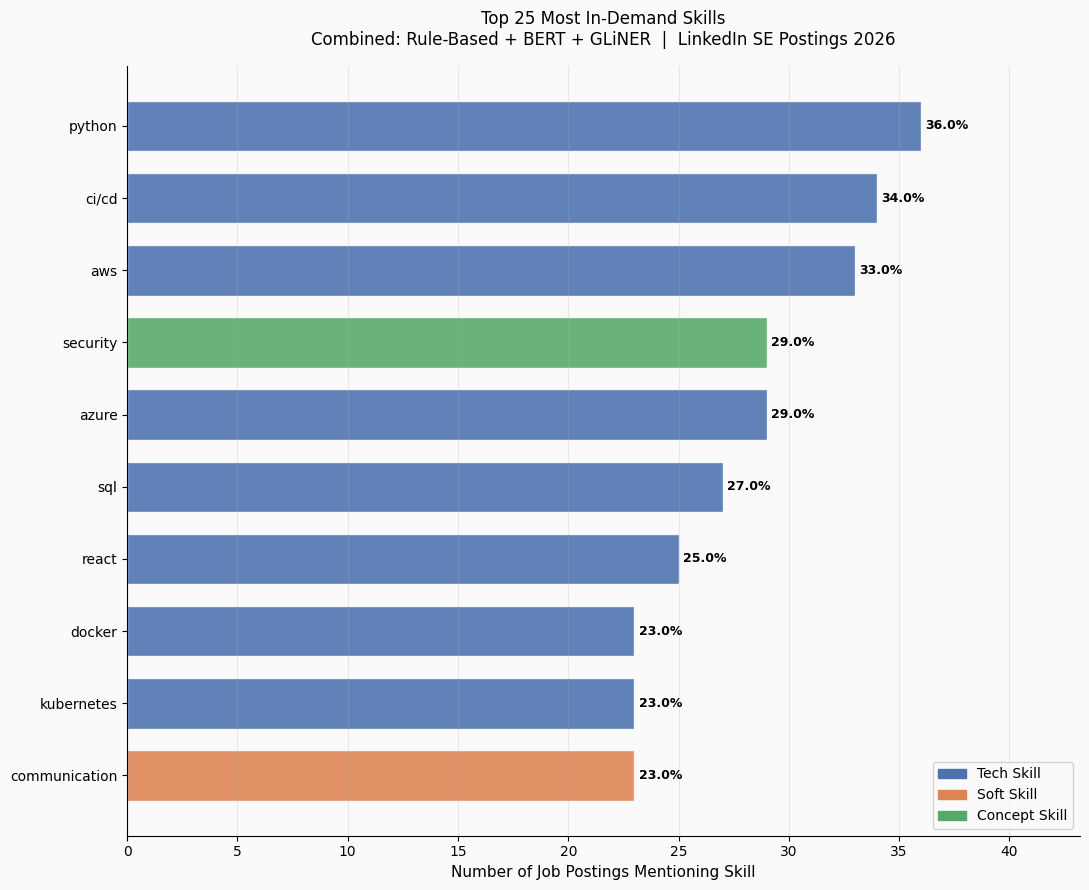

In [ ]:
# Top 10 skills
top10  = freq_table.head(10).sort_values('doc_freq')
colors = [CAT_COLORS.get(c, '#888') for c in top10['category']]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(top10['skill'], top10['doc_freq'],
               color=colors, edgecolor='white', alpha=0.88, height=0.7)

for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{row["coverage_pct"]}%', va='center', fontsize=9, fontweight='bold')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k.replace('_',' ').title())
           for k, v in CAT_COLORS.items()]
ax.legend(handles=patches, fontsize=10, loc='lower right')
ax.set_xlabel('Number of Job Postings Mentioning Skill', fontsize=11)
ax.set_title('Top 25 Most In-Demand Skills\n'
             'Combined: Rule-Based + BERT + GLiNER  |  LinkedIn SE Postings 2026',
             pad=15, fontsize=12)
ax.set_xlim(0, top10['doc_freq'].max() * 1.20)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('trend_fig1_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Skill Demand by Seniority Level

In [ ]:
# Skills by seniority: ranked frequency table
sen_counts = df['Seniority'].value_counts().to_dict()

sen_skill = (
    trend_df.drop_duplicates(subset=['posting_id','skill'])
    .groupby(['Seniority','skill','category'])['posting_id']
    .nunique().reset_index(name='doc_freq')
)
sen_skill['sen_total']    = sen_skill['Seniority'].map(sen_counts)
sen_skill['coverage_pct'] = (
    sen_skill['doc_freq'] / sen_skill['sen_total'] * 100
).round(1)

# Ranked table per seniority level
print('TOP 10 SKILLS PER SENIORITY LEVEL  (Combined Models)')
print('=' * 60)
for level in ['Junior','Mid','Senior']:
    sub = (
        sen_skill[sen_skill['Seniority']==level]
        .sort_values('coverage_pct', ascending=False)
        .head(10)
    )
    n = sen_counts.get(level, 0)
    print(f'\n{level.upper()} ({n} postings)')
    print(f'  {"RANK":<5} {"SKILL":<28} {"CATEGORY":<18} {"COVERAGE"}')
    print('  ' + '-' * 58)
    for i, (_, r) in enumerate(sub.iterrows(), 1):
        bar = '█' * int(r['coverage_pct'] / 5)
        print(f'  {i:<5} {r["skill"]:<28} {r["category"]:<18} '
              f'{r["coverage_pct"]:>5.1f}%  {bar}')

sen_skill.to_csv('trend_skills_by_seniority.csv', index=False)
print('\nSaved → trend_skills_by_seniority.csv')

TOP 10 SKILLS PER SENIORITY LEVEL  (Combined Models)

JUNIOR (3 postings)
  RANK  SKILL                        CATEGORY           COVERAGE
  ----------------------------------------------------------
  1     aws                          TECH_SKILL          66.7%  █████████████
  2     analytical                   SOFT_SKILL          66.7%  █████████████
  3     problem-solving              SOFT_SKILL          66.7%  █████████████
  4     sql                          TECH_SKILL          66.7%  █████████████
  5     python                       TECH_SKILL          66.7%  █████████████
  6     acumatica                    TECH_SKILL          33.3%  ██████
  7     airflow                      TECH_SKILL          33.3%  ██████
  8     accounting                   TECH_SKILL          33.3%  ██████
  9     caching                      CONCEPT_SKILL       33.3%  ██████
  10    data pipeline                CONCEPT_SKILL       33.3%  ██████

MID (49 postings)
  RANK  SKILL                       

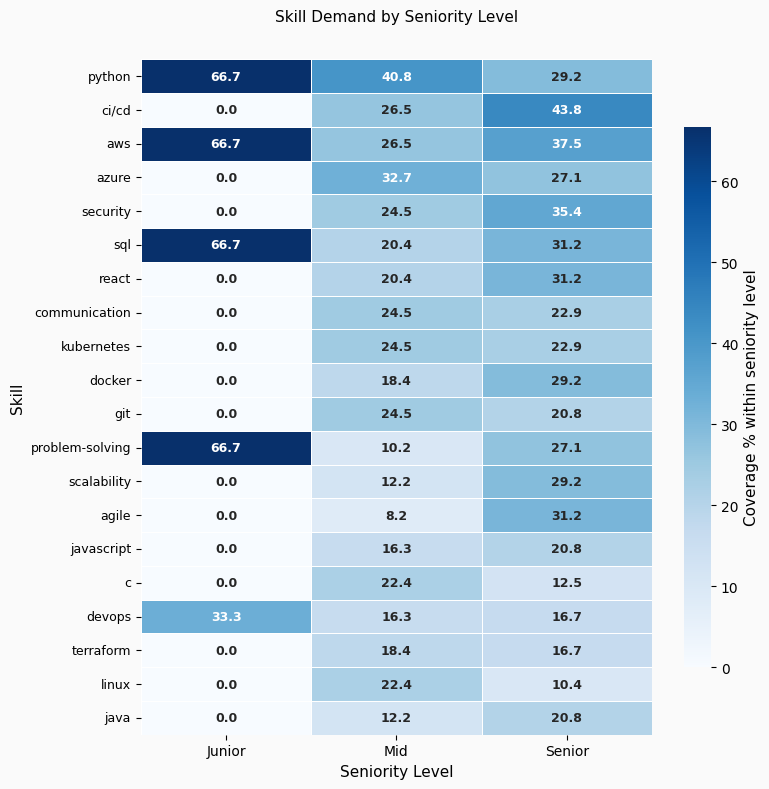

Saved → trend_fig4_seniority_heatmap.png


In [ ]:
# Heatmap — Top 20 skills × seniority
top20 = freq_table.head(20)['skill'].tolist()

pivot_sen = (
    sen_skill[sen_skill['skill'].isin(top20)]
    .pivot_table(index='skill', columns='Seniority',
                 values='coverage_pct', fill_value=0)
)
for col in ['Junior','Mid','Senior']:
    if col not in pivot_sen.columns:
        pivot_sen[col] = 0
pivot_sen = pivot_sen[['Junior','Mid','Senior']]
pivot_sen = pivot_sen.reindex([s for s in top20 if s in pivot_sen.index])

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    pivot_sen, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label':'Coverage % within seniority level','shrink':0.8},
    annot_kws={'size': 9, 'weight': 'bold'}
)
ax.set_title('Skill Demand by Seniority Level\n',
             pad=15, fontsize=11)
ax.set_xlabel('Seniority Level', fontsize=11)
ax.set_ylabel('Skill', fontsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=9)
ax.tick_params(axis='x', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('trend_fig4_seniority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → trend_fig4_seniority_heatmap.png')

### 9.3 Word Clouds by Skill Category

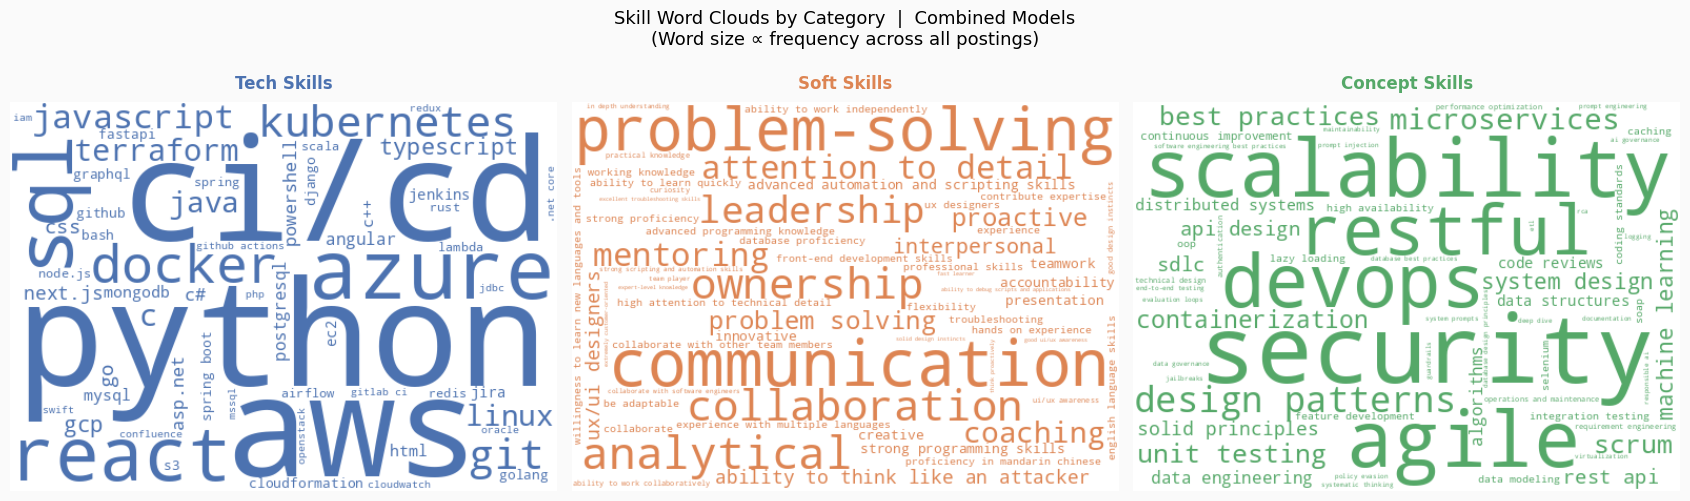

Saved → trend_fig7_wordclouds.png


In [ ]:
# Word clouds — one per skill category
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess
    subprocess.run(['pip','install','wordcloud','-q'], check=True)
    from wordcloud import WordCloud

cats_wc   = ['TECH_SKILL','SOFT_SKILL','CONCEPT_SKILL']
cat_names = ['Tech Skills','Soft Skills','Concept Skills']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Skill Word Clouds by Category  |  Combined Models\n'
             '(Word size ∝ frequency across all postings)',
             fontsize=13, y=1.02)

for ax, cat, name in zip(axes, cats_wc, cat_names):
    freq_dict = (
        trend_df[trend_df['category']==cat]
        .drop_duplicates(subset=['posting_id','skill'])
        ['skill'].value_counts().to_dict()
    )
    if not freq_dict:
        ax.text(0.5,0.5,'No data',ha='center',va='center')
        ax.set_title(name); ax.axis('off'); continue

    wc = WordCloud(
        width=520, height=370,
        background_color='white',
        color_func=lambda *a, **k: CAT_COLORS[cat],
        max_words=60,
        prefer_horizontal=0.80,
        collocations=False
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name, fontsize=12, pad=10,
                 color=CAT_COLORS[cat], fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('trend_fig7_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → trend_fig7_wordclouds.png')

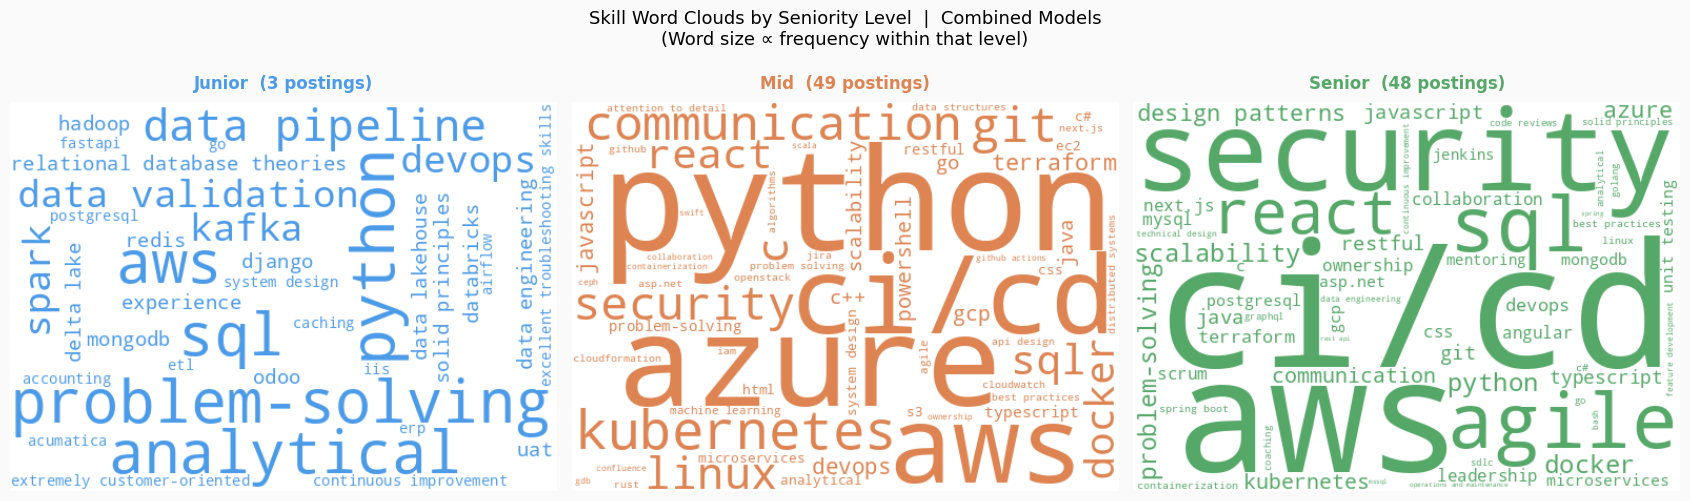

Saved → trend_fig8_seniority_wordclouds.png


In [ ]:
# Word clouds — one per seniority level
levels_wc  = ['Junior','Mid','Senior']
lev_colors = {'Junior':'#4C9BE8','Mid':'#DD8452','Senior':'#55A868'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Skill Word Clouds by Seniority Level  |  Combined Models\n'
             '(Word size ∝ frequency within that level)',
             fontsize=13, y=1.02)

for ax, level in zip(axes, levels_wc):
    freq_dict = (
        trend_df[trend_df['Seniority']==level]
        .drop_duplicates(subset=['posting_id','skill'])
        ['skill'].value_counts().to_dict()
    )
    if not freq_dict:
        ax.text(0.5,0.5,'No data',ha='center',va='center')
        ax.set_title(level); ax.axis('off'); continue

    wc = WordCloud(
        width=520, height=370,
        background_color='white',
        color_func=lambda *a, **k: lev_colors[level],
        max_words=60,
        prefer_horizontal=0.80,
        collocations=False
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{level}  ({sen_counts.get(level,0)} postings)',
                 fontsize=12, pad=10,
                 color=lev_colors[level], fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('trend_fig8_seniority_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → trend_fig8_seniority_wordclouds.png')

### 9.5  Trend Analysis Summary Report


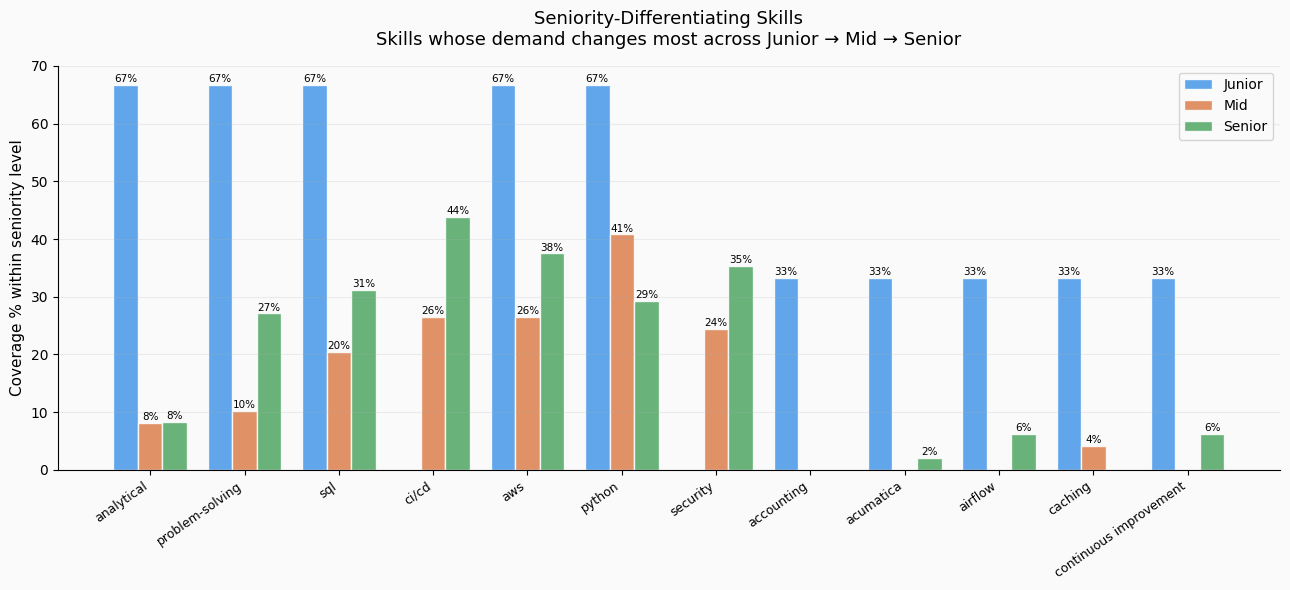

In [ ]:
# Fig T5: Seniority-differentiating skills (grouped bar)
# Skills whose coverage changes most from Junior → Mid → Senior
pivot_full = (
    sen_skill.pivot_table(index='skill', columns='Seniority',
                          values='coverage_pct', fill_value=0)
)
for col in ['Junior','Mid','Senior']:
    if col not in pivot_full.columns:
        pivot_full[col] = 0

pivot_full['spread'] = (
    pivot_full[['Junior','Mid','Senior']].max(axis=1) -
    pivot_full[['Junior','Mid','Senior']].min(axis=1)
)
top_diff = pivot_full.nlargest(12, 'spread')[['Junior','Mid','Senior']]

x = np.arange(len(top_diff));  w = 0.26
sen_colors = {'Junior': '#4C9BE8', 'Mid': '#DD8452', 'Senior': '#55A868'}

fig, ax = plt.subplots(figsize=(13, 6))
for i, (level, color) in enumerate(sen_colors.items()):
    bars = ax.bar(x + (i-1)*w, top_diff[level],
                  w, label=level, color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, top_diff[level]):
        if val > 2:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.0f}%', ha='center', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(top_diff.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Coverage % within seniority level')
ax.set_title('Seniority-Differentiating Skills\n'
             'Skills whose demand changes most across Junior → Mid → Senior',
             pad=15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('trend_fig5_seniority_diff.png', dpi=150, bbox_inches='tight')
plt.show()
